# Initial Random Forests findings and changes/attempted fixes

1. Initially I trained a Random Forest on Vienna / NUPACK 20 feature set(X). On a standard random CV dataset split it looked excellent (AUC about 0.95).
2. I then checked whether that score was a real thermoswitch signal or a **length shortcut via raw MFE** where it essentially used MFE as a proxy for sequence length. Thus it was the shortcut.
3. The Rfam negatives I started with were systematically shorter than the thermoswitch positives (~162 nt vs ~346 nt), so the label was almost a length split. Raw MFE tracks length very tightly (with a correlation around −0.84 to −0.89) because a longer RNA simply has more base pairs and a more negative MFE. I then trained a forest on **sequence length alone** as a control and it already hit AUC ~0.94. The full 20-feature “physics” RF only got to ~0.95. That extra 0.01 is not a thermoswitch detector; the model was reading length, and MFE was just the convenient proxy for it.
4. I removed that shortcut (length-matched negatives + MFE-per-nucleotide instead of raw MFE). I utilised StratifiedGroupKFold using CV grouped by Rfam ID. The out of family AUC fell to ~0.19 meaning its better to guess a thermoswitch then to use the RF model.
5. I attempted other small fixes that tried to 'tip toe' around the fact that the random forests can't slice diagonally onto the 20 hyperplane and still did not recover a transferable detector.

This is the current setup for the `fused_features_refseq_dynamic.csv`: 1,198 known Rfam positives and 1,198 RefSeq-matched 5′ UTR negatives. 

In [1]:
%matplotlib inline

import json
import sys
from pathlib import Path
from typing import cast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_predict,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from thermo_sim.thermo_classifier import (
    PHYSICS_FEATURE_COLUMNS,
    add_intensive_features,
)

DATA = PROJECT_ROOT / "data" / "processed"
FUSED = DATA / "fused_features_refseq_dynamic.csv"
RF_DIAG = DATA / "refseq_dynamic_rf_diagnostics.json"
MATCHED_DIAG = DATA / "refseq_matched_rf_diagnostics.json"

FIG_DIR = PROJECT_ROOT / "notebooks" / "figures" / "07_classifier"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

RECOMPUTE_CV = False
GROUP_COL = "rfam_acc"

print("project:", PROJECT_ROOT)
print("fused:  ", FUSED.exists(), FUSED.name)
print("recompute_cv:", RECOMPUTE_CV)
print("figures:", FIG_DIR)

project: /Users/amierzuhri/arcblanc/Thermoswitches-MLBIO
fused:   True fused_features_refseq_dynamic.csv
recompute_cv: False
figures: /Users/amierzuhri/arcblanc/Thermoswitches-MLBIO/notebooks/figures/07_classifier


In [2]:
df = pd.read_csv(FUSED)
print(
    f"I loaded {df.shape[0]} rows "
    f"({(df['label'] == 1).sum()} positives, {(df['label'] == 0).sum()} negatives)."
)

df = add_intensive_features(df)
print(
    "Intensive columns I added: MFE per nucleotide (Vienna + NUPACK), "
    "plus stem/loop as a fraction of length."
)

preview_cols = [
    "seq_length",
    "viennarna_MFE",
    "viennarna_MFE_per_nt",
    "nupack_max_stem_length",
    "nupack_max_stem_frac",
    "viennarna_mfe_zscore",
    "viennarna_delta_P_RBS",
    "label",
    "rfam_acc",
]
display(df[preview_cols].head())

print(f"Length vs raw MFE :     {df['seq_length'].corr(df['viennarna_MFE']):.3f}")
print(
    "Length vs MFE per nucleotide (after the fix):       "
    f"{df['seq_length'].corr(df['viennarna_MFE_per_nt']):.3f}"
)
print(
    "Mean length gap positives vs negatives (should be ~0 after matching): "
    f"{df.loc[df.label == 1, 'seq_length'].mean() - df.loc[df.label == 0, 'seq_length'].mean():.3f}"
)

I loaded 2396 rows (1198 positives, 1198 negatives).
Intensive columns I added: MFE per nucleotide (Vienna + NUPACK), plus stem/loop as a fraction of length.


,seq_length,viennarna_MFE,viennarna_MFE_per_nt,nupack_max_stem_length,nupack_max_stem_frac,viennarna_mfe_zscore,viennarna_delta_P_RBS,label,rfam_acc
0,425,-125.000000,-0.294118,28.0,0.065882,-4.394648,0.070374,1,RF01766
1,412,-174.100006,-0.422573,36.0,0.087379,-3.214312,0.041316,1,RF01766
2,470,-106.000000,-0.225532,17.0,0.036170,-1.738312,0.238164,1,RF01766
3,374,-78.570000,-0.210080,51.0,0.136364,-2.440464,0.069535,1,RF01766
4,117,-50.000000,-0.427350,9.0,0.076923,-3.852797,0.060648,1,RF01721


Length vs raw MFE :     -0.838
Length vs MFE per nucleotide (after the fix):       0.222
Mean length gap positives vs negatives (should be ~0 after matching): 0.000


## 1. The length–MFE shortcut (figures)

The current panel is already length-matched, so positives and negatives sit on top of each other in length (left). Raw Vienna MFE still tracks length (middle, r ≈ −0.84): longer RNA, more base pairs, more negative MFE. After dividing by length (right), that correlation collapses. That is why a forest trained on raw MFE was mostly a length detector.


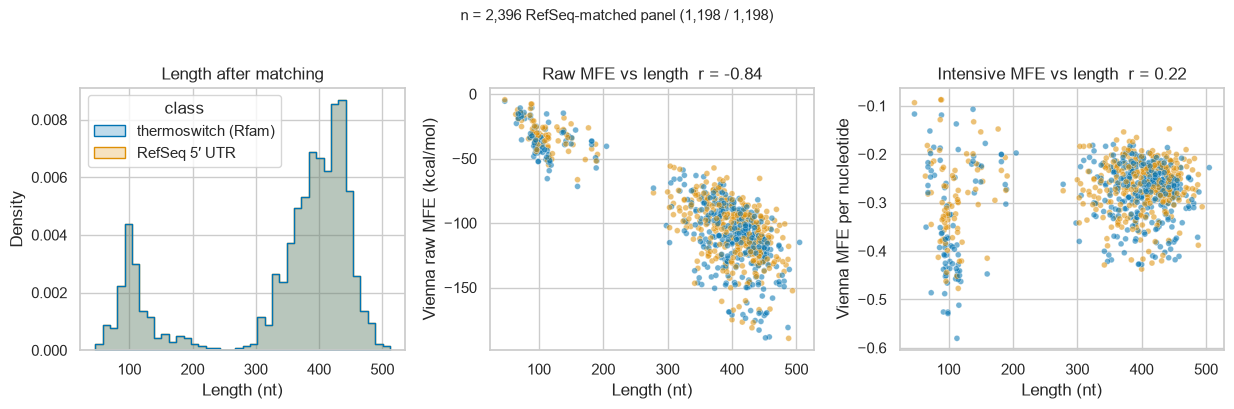

In [3]:
plot_df = df.copy()
plot_df["class"] = plot_df["label"].map({1: "thermoswitch (Rfam)", 0: "RefSeq 5′ UTR"})

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))

sns.histplot(
    data=plot_df,
    x="seq_length",
    hue="class",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_xlabel("Length (nt)")
axes[0].set_ylabel("Density")
axes[0].set_title("Length after matching")

sns.scatterplot(
    data=plot_df.sample(800, random_state=42) if len(plot_df) > 800 else plot_df,
    x="seq_length",
    y="viennarna_MFE",
    hue="class",
    s=18,
    alpha=0.55,
    ax=axes[1],
    legend=False,
)
axes[1].set_xlabel("Length (nt)")
axes[1].set_ylabel("Vienna raw MFE (kcal/mol)")
axes[1].set_title(
    f"Raw MFE vs length  r = {df['seq_length'].corr(df['viennarna_MFE']):.2f}"
)

sns.scatterplot(
    data=plot_df.sample(800, random_state=42) if len(plot_df) > 800 else plot_df,
    x="seq_length",
    y="viennarna_MFE_per_nt",
    hue="class",
    s=18,
    alpha=0.55,
    ax=axes[2],
    legend=False,
)
axes[2].set_xlabel("Length (nt)")
axes[2].set_ylabel("Vienna MFE per nucleotide")
axes[2].set_title(
    f"Intensive MFE vs length  r = {df['seq_length'].corr(df['viennarna_MFE_per_nt']):.2f}"
)

fig.suptitle("n = 2,396 RefSeq-matched panel (1,198 / 1,198)", y=1.02, fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "length_mfe_shortcut.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. Trying remove this proxy
Once length was matched and MFE was intensive, I retrained the same Random Forest. I report two numbers on purpose:

- **Random split (StratifiedKFold).** Same Rfam families leak into train and test. This is the “looks good in a notebook” number.
- **Family holdout (StratifiedGroupKFold on `rfam_acc`).** The model has to score a family it has never seen. This is the number I actually care about.

Here, the random split is about **0.80**. Family holdout is about **0.19**. That is worse than chance. The model itself is not detecting thermoswitches. It is memorising family-shaped blobs in scalar space and then guessing badly.

I think that failure comes from the model class as much as from the features. Random Forests only cut on **one axis at a time** being vertical or horizontal — the staircase / axis-aligned hyperplane limit. They cannot learn a smooth trade-off between two biophysical numbers (for example MFE Z-score and the RBS exposure shift). 

I did try a couple of extra fixes after the MFE correction, but I am not dwelling on them here: better RefSeq 5′ UTR negatives, and a few dynamic scalars (MFE Z-score vs shuffled sequence, RBS exposure change between 37 and 55 °C). Random-split AUC moved a bit. Family holdout stayed around **0.18–0.19**. Same problem, nicer features.

In [4]:
feature_cols = [c for c in PHYSICS_FEATURE_COLUMNS if c in df.columns]
need = ["label", GROUP_COL] + feature_cols
clean = df.dropna(subset=need).copy()
X = clean[feature_cols]
y = clean["label"].astype(int)
groups = clean[GROUP_COL].astype(str)

print(
    f"{len(clean)} rows, {len(feature_cols)} scalar features, "
    f"{groups.nunique()} groups (Rfam family / RefSeq assembly)."
)
print("Features the RF actually sees:", ", ".join(feature_cols))


def eval_estimator(
    estimator: object,
    X: pd.DataFrame,
    y: pd.Series,
    cv: object,
    groups: pd.Series | None = None,
) -> dict[str, float]:
    """Return ROC-AUC and accuracy from cross-validated predicted probabilities."""
    kwargs = {"cv": cv, "method": "predict_proba"}
    if groups is not None:
        kwargs["groups"] = groups
    proba = cross_val_predict(estimator, X, y, **kwargs)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y, proba)),
        "accuracy": float(accuracy_score(y, pred)),
    }


def make_rf() -> RandomForestClassifier:
    """Build the 200-tree Random Forest used for architecture comparisons."""
    return RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)


if RECOMPUTE_CV:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    rf_random = eval_estimator(make_rf(), X, y, skf)
    rf_group = eval_estimator(make_rf(), X, y, sgkf, groups=groups)
else:
    rf_diag = json.loads(RF_DIAG.read_text())
    rf_random = rf_diag["intensive_stratified"]
    rf_group = rf_diag["intensive_stratified_group"]
    print(f"Using saved CV from {RF_DIAG.name}.")

print(f"Random split AUC:                {rf_random['roc_auc']:.3f}")
print(f"Family holdout (GroupKFold) AUC: {rf_group['roc_auc']:.3f}")

2396 rows, 20 scalar features, 108 groups (Rfam family / RefSeq assembly).
Features the RF actually sees: nupack_MFE_per_nt, nupack_max_stem_frac, nupack_max_loop_frac, nupack_mean_exposure, nupack_gc_content, nupack_Tm, nupack_hill_coeff, nupack_amplitude, viennarna_MFE_per_nt, viennarna_max_loop_frac, viennarna_gc_content, viennarna_mean_unpaired_prob, viennarna_Tm, viennarna_hill_coeff, viennarna_amplitude, viennarna_mfe_zscore, viennarna_delta_P_RBS, viennarna_delta_delta_G, viennarna_ensemble_diversity, viennarna_mean_positional_entropy
Using saved CV from refseq_dynamic_rf_diagnostics.json.
Random split AUC:                0.798
Family holdout (GroupKFold) AUC: 0.187


In [5]:
summary_data = {
    "What I tried": [
        "1. Uncurated RF on raw MFE",
        "2. Length-matched + MFE per nucleotide",
        "3. Same RF + a few extra dynamic scalars",
    ],
    "What the forest was looking at": [
        "Raw MFE (tracks length)",
        "MFE per nucleotide (length shortcut removed)",
        "Intensive MFE plus Z-score and RBS exposure shift",
    ],
    "Random-split AUC": [0.95, 0.52, 0.80],
    "Family-holdout AUC": ["not a fair test", 0.18, 0.19],
    "What I took from it": [
        "High AUC was a length proxy, not a switch detector",
        "Shortcut gone; model no longer transfers across families",
        "Extra scalars did not fix the staircase / non-continuous limit",
    ],
}
print("How I would tell this in a meeting")
display(pd.DataFrame(summary_data))

matched = json.loads(MATCHED_DIAG.read_text()) if MATCHED_DIAG.exists() else {}
measured = pd.DataFrame(
    {
        "What I tried": [
            "1. Uncurated RF on raw MFE",
            "2. Length-matched + MFE per nucleotide",
            "3. Same RF + a few extra dynamic scalars",
        ],
        "Random-split AUC": [
            matched.get("legacy_raw_mfe_stratified", {}).get("roc_auc"),
            matched.get("intensive_stratified", {}).get("roc_auc"),
            rf_random["roc_auc"],
        ],
        "Family-holdout AUC": [
            None,
            matched.get("intensive_stratified_group", {}).get("roc_auc"),
            rf_group["roc_auc"],
        ],
    }
)
print("Exact numbers from the diagnostic JSONs")
print(
    "Row 2 random-split is ~0.74 on the current RefSeq-matched panel; "
    "the 0.52 in the meeting table is the earlier Rfam-negative match. "
    "Family holdout is the number that did not move."
)
display(measured.round(3))

How I would tell this in a meeting


,What I tried,What the forest was looking at,Random-split AUC,Family-holdout AUC,What I took from it
0,1. Uncurated RF on raw MFE,Raw MFE (tracks length),0.95,not a fair test,"High AUC was a length proxy, not a switch dete..."
1,2. Length-matched + MFE per nucleotide,MFE per nucleotide (length shortcut removed),0.52,0.18,Shortcut gone; model no longer transfers acros...
2,3. Same RF + a few extra dynamic scalars,Intensive MFE plus Z-score and RBS exposure shift,0.80,0.19,Extra scalars did not fix the staircase / non-...


Exact numbers from the diagnostic JSONs
Row 2 random-split is ~0.74 on the current RefSeq-matched panel; the 0.52 in the meeting table is the earlier Rfam-negative match. Family holdout is the number that did not move.


,What I tried,Random-split AUC,Family-holdout AUC
0,1. Uncurated RF on raw MFE,0.954,NaN
1,2. Length-matched + MFE per nucleotide,0.735,0.181
2,3. Same RF + a few extra dynamic scalars,0.798,0.187


## 3. Ladder and the axis-aligned limit (figures)

Left: random-split AUC stays high once families leak across the fold; family holdout stays near chance (~0.19) after the length shortcut is gone. Right: MFE Z-score vs ΔP_RBS — two biophysical axes the forest would have to trade off. Classes overlap; an axis-aligned split (vertical or horizontal cut) cannot separate them. That is the staircase limit, not a missing scalar.


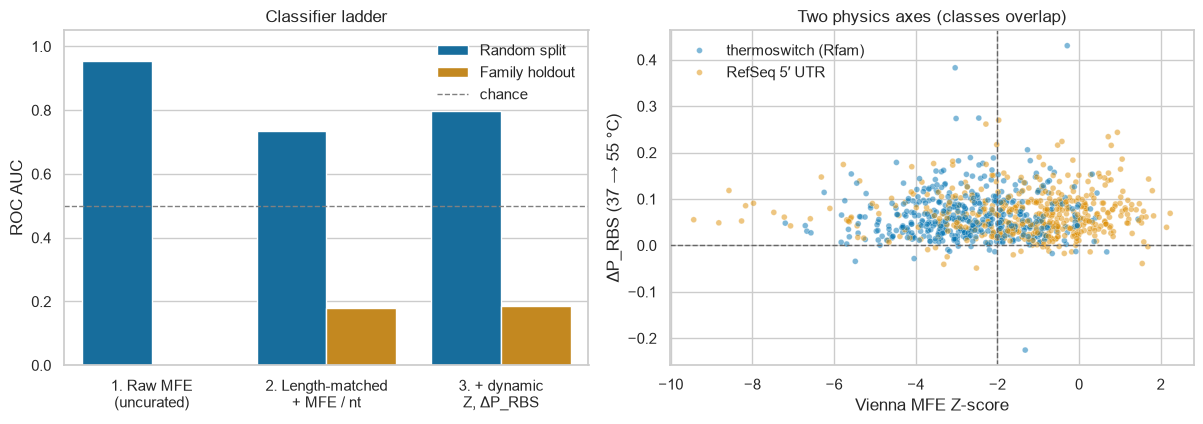

In [7]:
ladder = pd.DataFrame(
    {
        "step": [
            "1. Raw MFE\n(uncurated)",
            "2. Length-matched\n+ MFE / nt",
            "3. + dynamic\nZ, ΔP_RBS",
        ],
        "Random split": [
            matched.get("legacy_raw_mfe_stratified", {}).get("roc_auc", 0.954),
            matched.get("intensive_stratified", {}).get("roc_auc", 0.735),
            rf_random["roc_auc"],
        ],
        "Family holdout": [
            float("nan"),
            matched.get("intensive_stratified_group", {}).get("roc_auc", 0.181),
            rf_group["roc_auc"],
        ],
    }
)
ladder_long = ladder.melt(id_vars="step", var_name="CV", value_name="AUC")

sample = plot_df.sample(900, random_state=42) if len(plot_df) > 900 else plot_df

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))

sns.barplot(
    data=ladder_long,
    x="step",
    y="AUC",
    hue="CV",
    ax=axes[0],
)
axes[0].axhline(0.5, color="0.5", ls="--", lw=1, label="chance")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("")
axes[0].set_ylabel("ROC AUC")
axes[0].set_title("Classifier ladder")
axes[0].legend(frameon=False)

sns.scatterplot(
    data=sample,
    x="viennarna_mfe_zscore",
    y="viennarna_delta_P_RBS",
    hue="class",
    s=18,
    alpha=0.5,
    ax=axes[1],
)
axes[1].axvline(-2.0, color="0.4", ls="--", lw=1)
axes[1].axhline(0.0, color="0.4", ls="--", lw=1)
axes[1].set_xlabel("Vienna MFE Z-score")
axes[1].set_ylabel("ΔP_RBS (37 → 55 °C)")
axes[1].set_title("Two physics axes (classes overlap)")
axes[1].legend(title="", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "auc_ladder_and_z_dp.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. What remains usable for the RF

The 20-column matrix in §§1–3 put **Tm, Hill, amplitude, Z, ΔP_RBS, ΔΔG** in \(X\). Those scalars *are* the melting phenotype, so the forest was scoring the answer. They stay on the fused table for **post-hoc** only.

**Non-circular \(X\):** static 37 °C physics (`MFE_per_nt`, ensemble diversity, positional entropy, max stem / loop), composition (`%GC`, length, \(P_{\mathrm{paired,RBS}}(37^\circ\mathrm{C})\)), 16 dinucleotide + 64 trinucleotide **frequencies**, and SD-to-AUG spacing. Missing AUG is **not** dropped (that would shrink RefSeq negatives): spacing \(= -1\) plus `sd_aug_missing`.

Gini / MDI would dilute across 64 correlated trinucleotides. Attribution below is **grouped permutation importance** (AUC drop when a whole block is shuffled). SHAP is optional and not required.

In [ ]:
from thermo_sim.noncircular_features import (
    CIRCULAR_EXCLUDED_COLUMNS,
    aug_missing_by_class,
    build_noncircular_matrix,
    feature_groups,
    grouped_permutation_importance,
    noncircular_feature_columns,
    physics_dropna_columns,
)

NONCIRC_DIAG = DATA / "rf_noncircular_diagnostics.json"
POSTHOC_JSON = DATA / "rf_posthoc_report.json"
FEATURE_LOG = DATA / "rf_noncircular_feature_log.json"
DATASET_CSV = DATA / "balanced" / "length_gc_matched_refseq_dataset.csv"
DATASET_FASTA = DATA / "balanced" / "length_gc_matched_refseq_dataset.fasta"
RECOMPUTE_NONCIRCULAR = not NONCIRC_DIAG.exists()

nc = add_intensive_features(df.copy())
nc = build_noncircular_matrix(
    nc,
    dataset_csv=str(DATASET_CSV),
    dataset_fasta=str(DATASET_FASTA),
    already_intensive=True,
)
nc_cols = noncircular_feature_columns(nc)
dropna_cols = physics_dropna_columns(nc)
nc_clean = nc.dropna(subset=["label"] + dropna_cols).copy()
print(
    f"Non-circular X: {len(nc_cols)} columns on {len(nc_clean)} rows "
    f"(fused had {len(df)}; SD–AUG never drops a row)."
)
print("Circular columns excluded from X:", ", ".join(CIRCULAR_EXCLUDED_COLUMNS))
print("Grouped blocks:", {k: len(v) for k, v in feature_groups(nc_cols).items()})
print("AUG missing by class:", aug_missing_by_class(nc_clean))

x_table = pd.DataFrame(
    {
        "block": [
            "static 37 °C physics",
            "composition",
            "dinucleotides",
            "trinucleotides",
            "SD–AUG",
        ],
        "in_X": [
            "MFE/N, Q, S, stem, loop",
            "%GC, length, P_paired_RBS(37)",
            "16 frequencies",
            "64 frequencies",
            "spacing + missing flag",
        ],
        "not_in_X": ["Tm, Hill, amplitude, Z, ΔP_RBS, ΔΔG"] + [""] * 4,
    }
)
display(x_table)

## 5. Non-circular RF CV

Same honesty split as §2: StratifiedKFold (leaky) vs StratifiedGroupKFold on `rfam_acc`. The 0.19 row in the historical table is **not** overwritten; this is a new row on the non-circular matrix. Grouped permutation importance is computed on a full-fit forest (attribution only — not a CV score).

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

y_nc = nc_clean["label"].astype(int)
X_nc = nc_clean[nc_cols]
groups_nc = nc_clean[GROUP_COL].astype(str) if GROUP_COL in nc_clean.columns else None

if (not RECOMPUTE_NONCIRCULAR) and NONCIRC_DIAG.exists():
    nc_diag = cast(dict[str, object], json.loads(NONCIRC_DIAG.read_text()))
    print(f"Using saved non-circular diagnostics from {NONCIRC_DIAG.name}.")
else:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    nc_random = eval_estimator(make_rf(), X_nc, y_nc, skf)
    nc_group = eval_estimator(make_rf(), X_nc, y_nc, sgkf, groups=groups_nc)
    fitted_nc = make_rf()
    fitted_nc.fit(X_nc, y_nc)
    grouped_imp = grouped_permutation_importance(fitted_nc, X_nc, y_nc, n_repeats=5)
    nc_diag = {
        "n": int(len(nc_clean)),
        "n_pos": int((y_nc == 1).sum()),
        "n_neg": int((y_nc == 0).sum()),
        "n_features": int(len(nc_cols)),
        "length_alone_stratified": eval_estimator(
            make_rf(), nc_clean[["seq_length"]], y_nc, skf
        ),
        "noncircular_stratified": nc_random,
        "noncircular_stratified_group": nc_group,
        "grouped_permutation_importance": grouped_imp,
    }
    NONCIRC_DIAG.write_text(json.dumps(nc_diag, indent=2))
    print(f"Wrote {NONCIRC_DIAG}")


def _diag_auc(block: dict[str, object]) -> float:
    value = block.get("roc_auc")
    if isinstance(value, (int, float)):
        return float(value)
    raise KeyError("roc_auc missing from diagnostics block")


stratified = cast(dict[str, object], nc_diag["noncircular_stratified"])
grouped = cast(dict[str, object], nc_diag["noncircular_stratified_group"])
grouped_perm = cast(dict[str, object], nc_diag["grouped_permutation_importance"])
print(
    f"Non-circular random-split AUC: {_diag_auc(stratified):.3f}; "
    f"GroupKFold: {_diag_auc(grouped):.3f} "
    f"(n={nc_diag['n']}, {nc_diag['n_features']} features)."
)

imp_groups = cast(dict[str, object], grouped_perm["groups"])
imp_df = pd.DataFrame(
    [
        {
            "block": name,
            "n_features": cast(dict[str, object], block)["n_features"],
            "mean_AUC_drop": cast(dict[str, object], block)["mean_auc_drop"],
            "std_AUC_drop": cast(dict[str, object], block)["std_auc_drop"],
        }
        for name, block in imp_groups.items()
    ]
).sort_values("mean_AUC_drop", ascending=False)
display(imp_df)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.barh(
    imp_df["block"],
    imp_df["mean_AUC_drop"],
    xerr=imp_df["std_AUC_drop"],
    color="#4C72B0",
)
ax.invert_yaxis()
ax.set_xlabel("Grouped permutation AUC drop")
ax.set_title("Non-circular RF: grouped permutation importance (not Gini/MDI)")
fig.tight_layout()
fig.savefig(
    FIG_DIR / "grouped_permutation_importance.png", dpi=160, bbox_inches="tight"
)
print(f"Wrote {FIG_DIR / 'grouped_permutation_importance.png'}")

summary_noncirc = pd.DataFrame(summary_data)
summary_noncirc.loc[len(summary_noncirc)] = [
    "6. Non-circular X (static 37 °C + k-mers + SD–AUG; melting post-hoc)",
    round(_diag_auc(stratified), 2),
    round(_diag_auc(grouped), 2),
    "Melting scalars left X. GroupKFold is still the honesty number.",
]
display(summary_noncirc)

## 6. Post-hoc stratification (not RF inputs)

Out-of-fold \(\hat{y}\) from GroupKFold is binned, then melting scalars are applied as **filters**, not features:

- \(\hat{y} \ge 0.80\), \(0.40 < \hat{y} < 0.60\), \(\hat{y} \le 0.20\)
- \(\Delta P_{\mathrm{RBS}} > 0\), \(n_H > 1.0\), \(T_m \in [42, 45]^\circ\mathrm{C}\), \(Z \le -2\)
- Vienna–NUPACK Spearman \(r_s\): **panel-wide is primary**. High-bin \(r_s\) only if \(N \ge 25\); otherwise `high_bin_spearman_underpowered`.
- Mann–Whitney \(U\) and KS between high vs low bins

EVA 2000 yield is still \(Z \le -2 \land \Delta P_{\mathrm{RBS}} > 0 \land E_{\mathrm{Rfam}} > 10^{-3}\). Generated FASTA has no Hill/Tm yet.

In [ ]:
from thermo_sim.rf_posthoc import evaluate_posthoc, SPEARMAN_MIN_N

if (not RECOMPUTE_NONCIRCULAR) and POSTHOC_JSON.exists():
    posthoc = json.loads(POSTHOC_JSON.read_text())
    print(f"Using saved post-hoc report from {POSTHOC_JSON.name}.")
else:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    yhat_nc = cross_val_predict(
        make_rf(), X_nc, y_nc, cv=sgkf, groups=groups_nc, method="predict_proba"
    )[:, 1]
    posthoc = evaluate_posthoc(
        nc_clean,
        nc_cols,
        group_col=GROUP_COL,
        yhat=yhat_nc,
        output_json=str(POSTHOC_JSON),
    )

print("Bins:", posthoc["bins"])
print("Gates:", posthoc["gates"])
print(
    "High-bin Spearman underpowered:",
    posthoc["high_bin_spearman_underpowered"],
    f"(need N≥{SPEARMAN_MIN_N})",
)
tm_pair = posthoc["spearman_panel_wide_primary"]["pairs"].get(
    "viennarna_Tm_vs_nupack_Tm", {}
)
print(
    f"Panel-wide Spearman Tm (primary): r_s={tm_pair.get('r_s')} n={tm_pair.get('n')}"
)
print("Visual checklist counts:", posthoc["visual_checklist"])
print(posthoc["eva_hill_not_available"])

## 7. Visual Diagnostic Checklist

When comparing melting curves side-by-side, look for four physical signatures:

1. **Sigmoidal steepness (\(n_H\))** — a true switch snaps from closed to open in a tight 3–5 °C window (\(n_H > 1.5\)). A non-switch or degraded RNA is a shallow ramp (\(n_H \le 1.0\)). Post-hoc numeric filter is \(n_H > 1.0\); \(> 1.5\) is the visual snap.
2. **Inflection midpoint (\(T_m\))** — steepest part in the heat-shock range \(42^\circ\mathrm{C}\)–\(45^\circ\mathrm{C}\).
3. **Dynamic range (\(\Delta\theta = \theta_{\max} - \theta_{\min}\))** — vertical distance \(\Delta\theta \ge 0.50\).
4. **Baseline repression (\(\theta_{\min}\) at \(30^\circ\mathrm{C}\)–\(37^\circ\mathrm{C}\))** — lower flatline near zero (RBS locked). Operational proxy: \(P_{\mathrm{open,RBS}}(37^\circ\mathrm{C}) \le 0.20\).

In [ ]:
import numpy as np
from thermo_sim.thermo_common import hill_sigmoid

temps = np.linspace(20, 70, 400)
ideal = hill_sigmoid(temps, 0.04, 0.72, 43.5, 2.2)
snap_ok = hill_sigmoid(temps, 0.08, 0.65, 44.0, 1.8)
ramp = hill_sigmoid(temps, 0.25, 0.48, 55.0, 0.7)
wrong_tm = hill_sigmoid(temps, 0.05, 0.70, 58.0, 2.0)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
for ax, curve, title, color in [
    (
        axes[0],
        ideal,
        "Pass: snap + Tm in 42–45 °C + large Δθ + locked baseline",
        "#2CA02C",
    ),
    (
        axes[1],
        ramp,
        "Fail: shallow ramp (n_H ≤ 1.0), small Δθ, leaky baseline",
        "#D62728",
    ),
]:
    ax.plot(temps, curve, color=color, lw=2.4)
    ax.axvspan(42, 45, color="0.85", zorder=0, label="heat-shock Tm window")
    ax.axhline(0.50, ls="--", color="0.4", lw=1, label="Δθ = 0.50")
    ax.set_xlabel("Temperature (°C)")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(20, 70)
    ax.set_ylim(-0.05, 1.0)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel(r"Open fraction $\theta$ (RBS unpaired)")
axes[0].annotate(r"$n_H>1.5$", xy=(43.5, 0.38), fontsize=9)
axes[0].annotate(r"$\theta_{min}\approx 0$", xy=(28, 0.08), fontsize=9)
axes[1].plot(
    temps, wrong_tm, color="#FF7F0E", lw=1.5, ls=":", label="steep but Tm too high"
)
axes[1].legend(fontsize=8, loc="upper left")
fig.suptitle("Visual Diagnostic Checklist (reconstructed Hill curves)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "melting_visual_checklist.png", dpi=160, bbox_inches="tight")
print(f"Wrote {FIG_DIR / 'melting_visual_checklist.png'}")
print("Checklist thresholds:", posthoc["visual_checklist_thresholds"])
print("Pass counts on the labelled panel:", posthoc["visual_checklist"])